# US Equities — Exploratory Data Analysis

**Docker image**: `ml4t`

## Purpose

Profile the **US equities panel**: its schema, its price conventions, and — the part
that decides whether it can carry a backtest — the shape of its coverage through time.

The panel is sourced from the legacy Quandl WIKI end-of-day file: community-maintained,
free, and discontinued in March 2018. That provenance is not trivia. It determines what
the panel can and cannot tell us, and this notebook's job is to find out which.

## Learning objectives

- Load the panel via `data.load_us_equities` and inspect its canonical schema.
- Distinguish raw from split/dividend-adjusted price columns.
- Chart how many symbols the panel covers in each year, and when symbols enter and leave it.
- Read the coverage chart as evidence about the *data collection process*, not about the market.
- Check OHLC invariants and null rates across the full panel.

## How this notebook relates to `15_survivorship_bias_detection`

This notebook establishes **what is in the file**. It ends by surfacing one anomaly in the
coverage record that it deliberately does not resolve.

`15_survivorship_bias_detection` picks that anomaly up and asks the follow-on question:
*given what the panel records about symbols that leave it, how wrong is a backtest that
ignores them?* Read this one first; it is the shorter one, and it sets up the problem.

## Book reference

§2.2 ("The Asset-Class Market Data Landscape" — Equities).

## Prerequisites

`data` package on `PYTHONPATH`; the panel's parquet present at
`ML4T_DATA_PATH/equities/market/us_equities/`. Run
`python data/equities/market/us_equities/download.py` if missing.

In [1]:
"""US Equities — Exploratory data analysis of the US equities panel."""

import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display

from data import load_us_equities
from utils.data_quality import check_ohlc_invariants
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all symbols; a positive value subsets for fast execution

## 1. Load and inspect

In [3]:
wiki = load_us_equities()

if MAX_SYMBOLS:
    keep = sorted(wiki["symbol"].unique().to_list())[:MAX_SYMBOLS]
    wiki = wiki.filter(pl.col("symbol").is_in(keep))

print("=== US equities panel ===")
print(f"Shape: {wiki.shape}")
print(f"Columns: {wiki.columns}")

=== US equities panel ===
Shape: (15389314, 14)
Columns: ['symbol', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'ex-dividend', 'split_ratio', 'adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume']


In [4]:
print("Schema:")
for col, dtype in wiki.schema.items():
    print(f"  {col}: {dtype}")

Schema:
  symbol: String
  timestamp: Date
  open: Float64
  high: Float64
  low: Float64
  close: Float64
  volume: Float64
  ex-dividend: Float64
  split_ratio: Float64
  adj_open: Float64
  adj_high: Float64
  adj_low: Float64
  adj_close: Float64
  adj_volume: Float64


### Raw versus adjusted prices

This panel carries **both** price conventions. Which one you reach for is not a
style preference — it changes the numbers.

| Column type | Columns | Use for |
|---|---|---|
| Raw | `open`, `high`, `low`, `close`, `volume` | Analysis at actually traded price levels |
| Adjusted | `adj_open`, `adj_high`, `adj_low`, `adj_close`, `adj_volume` | Return calculations and backtesting |

The adjusted columns are meant to absorb splits and dividends so that a return computed
across a corporate action is a return an investor could have earned. Use `adj_*` for
returns; use the raw columns when you need the price a trade would have printed at.

The panel also ships the two corporate-action inputs themselves, `ex-dividend` and
`split_ratio`, which is what lets `02_corporate_actions` verify the adjustment on a
worked example rather than take it on trust. That check passes on AAPL. It does not
pass everywhere — see `15_survivorship_bias_detection` §3.

## 2. Coverage: the cross-section

In [5]:
print("=== Coverage ===")
print(f"Unique symbols: {wiki['symbol'].n_unique():,}")
print(f"Date range: {wiki['timestamp'].min()} to {wiki['timestamp'].max()}")
print(f"Total rows: {len(wiki):,}")

=== Coverage ===
Unique symbols: 3,199
Date range: 1962-01-02 to 2018-03-27
Total rows: 15,389,314


In [6]:
# One row per symbol: when it enters the panel, when it leaves, how long it trades.
dataset_end = wiki.select(pl.col("timestamp").max()).item()

lifespans = (
    wiki.group_by("symbol")
    .agg(
        [
            pl.len().alias("days"),
            pl.col("timestamp").min().alias("first_date"),
            pl.col("timestamp").max().alias("last_date"),
            pl.col("adj_close").mean().alias("avg_price"),
        ]
    )
    .with_columns(
        [
            pl.col("first_date").dt.year().alias("entry_year"),
            pl.col("last_date").dt.year().alias("exit_year"),
            (pl.col("last_date") < dataset_end).alias("leaves_early"),
        ]
    )
)

Per-symbol coverage distribution — number of trading days and mean adjusted price.

In [7]:
lifespans.select(["days", "avg_price"]).describe()

statistic,days,avg_price
str,f64,f64
"""count""",3199.0,3199.0
"""null_count""",0.0,0.0
"""mean""",4810.663957,118.245432
"""std""",2621.170846,2893.682465
"""min""",4.0,0.669129
"""25%""",2611.0,11.539385
"""50%""",4974.0,18.519854
"""75%""",6666.0,29.777315
"""max""",14155.0,132897.234865


## 3. Coverage through time

The cross-section above says how many symbols the panel holds *in total*. It says nothing
about **when**. A panel of 3,199 symbols could mean 3,199 symbols quoted every year, or a
universe that grows and shrinks as firms list and delist.

Two views answer this:

- **Universe size** — how many distinct symbols are quoted in each calendar year.
- **Entries and exits** — how many symbols record their *first* observation in each year,
  and how many record their *last*.

For a panel tracking a real equity market, both flows should run continuously: firms IPO
every year, and firms are acquired or fail every year.

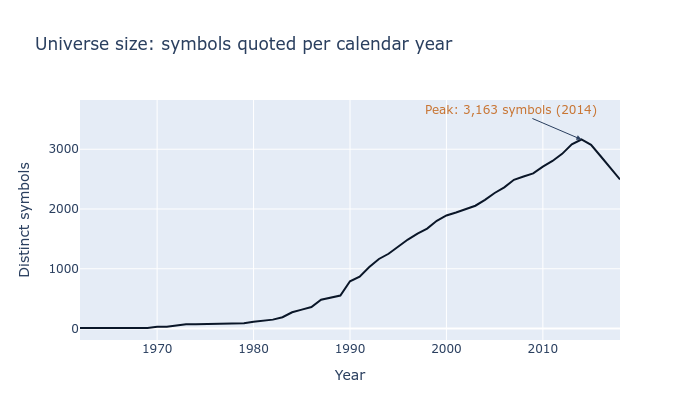

In [8]:
active_by_year = (
    wiki.select(pl.col("timestamp").dt.year().alias("year"), "symbol")
    .group_by("year")
    .agg(pl.col("symbol").n_unique().alias("active"))
    .sort("year")
)

peak = active_by_year.sort("active", descending=True).head(1)
peak_year, peak_active = peak["year"][0], peak["active"][0]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=active_by_year["year"].to_list(),
        y=active_by_year["active"].to_list(),
        mode="lines",
        name="Symbols quoted",
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.add_annotation(
    x=peak_year,
    y=peak_active,
    text=f"Peak: {peak_active:,} symbols ({peak_year})",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-30,
    font=dict(color=COLORS["copper"]),
)
fig.update_layout(
    title="Universe size: symbols quoted per calendar year",
    xaxis_title="Year",
    yaxis_title="Distinct symbols",
    height=420,
)
fig.show()

The universe grows for fifty years, peaks, and then declines. A market does not do that.
A *data collection process* does. Hold that thought; the next chart names the mechanism.

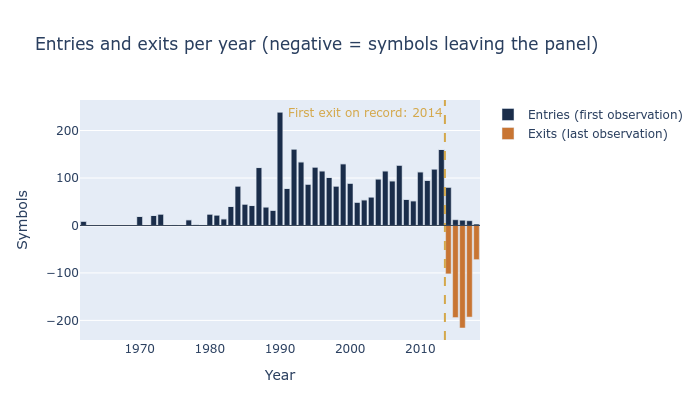

In [9]:
entries = (
    lifespans.group_by("entry_year").agg(pl.len().alias("entries")).rename({"entry_year": "year"})
)
# A symbol whose last observation is the panel's last date has not left — it is still quoted.
exits = (
    lifespans.filter(pl.col("leaves_early"))
    .group_by("exit_year")
    .agg(pl.len().alias("exits"))
    .rename({"exit_year": "year"})
)

years = pl.DataFrame(
    {"year": list(range(lifespans["entry_year"].min(), lifespans["exit_year"].max() + 1))}
)
flows = (
    years.join(entries, on="year", how="left")
    .join(exits, on="year", how="left")
    .with_columns([pl.col("entries").fill_null(0), pl.col("exits").fill_null(0)])
    .sort("year")
)

first_exit_year = flows.filter(pl.col("exits") > 0)["year"].min()

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=flows["year"].to_list(),
        y=flows["entries"].to_list(),
        name="Entries (first observation)",
        marker_color=COLORS["slate"],
    )
)
fig.add_trace(
    go.Bar(
        x=flows["year"].to_list(),
        y=[-n for n in flows["exits"].to_list()],
        name="Exits (last observation)",
        marker_color=COLORS["copper"],
    )
)
fig.add_vline(x=first_exit_year - 0.5, line_dash="dash", line_color=COLORS["amber"])
fig.add_annotation(
    x=first_exit_year - 0.5,
    y=max(flows["entries"].to_list()),
    text=f"First exit on record: {first_exit_year}",
    showarrow=False,
    xanchor="right",
    font=dict(color=COLORS["amber"]),
)
fig.add_hline(y=0, line_color=COLORS["neutral"], line_width=1)
fig.update_layout(
    title="Entries and exits per year (negative = symbols leaving the panel)",
    xaxis_title="Year",
    yaxis_title="Symbols",
    barmode="relative",
    height=420,
)
fig.show()

## 4. What the exit record actually shows

Entries run continuously from 1962. Exits do not: **the panel records no symbol leaving
before 2014.**

Firms plainly did exit before 2014 — they were acquired, they went bankrupt, they went
private. Enron delisted in 2002. What the chart shows is therefore not a fact about the
equity market. It is a fact about the file: **exit information was not being captured until
roughly 2014, and started being captured around then.**

This is the tax on free, community-maintained data. The panel was assembled from the
symbols that existed when the project ran, each backfilled to its own IPO. Symbols that had
already died were never added, so their disappearance was never recorded. From 2014 the
panel is live, so symbols leaving it *are* recorded. Both flows then decay as contributors
drift away, until the feed stops in March 2018.

What follows for a backtest:

- Before 2014 the panel holds **only firms that survived to 2014**. A 1990s backtest run on
  it will not see a single failure, because none are there to see.
- From 2014 the panel does record exits, and can support survivorship-aware work.
- The absence of exits before 2014 is **absence of evidence**, not evidence that nothing
  left. We do not know what left. The panel cannot tell us.

In [10]:
exit_summary = (
    lifespans.filter(pl.col("leaves_early"))
    .group_by("exit_year")
    .agg(pl.len().alias("symbols"))
    .sort("exit_year")
    .rename({"exit_year": "year"})
)
exit_summary

year,symbols
i32,u32
2014,102
2015,194
2016,216
2017,193
2018,72


In [11]:
n_total = lifespans.height
n_left = lifespans.filter(pl.col("leaves_early")).height
n_still = n_total - n_left
first_year, last_year = lifespans["entry_year"].min(), flows["year"].max()

display(
    Markdown(
        f"**Coverage summary.** The panel holds **{n_total:,} symbols** over "
        f"**{first_year}–{last_year}**. **{n_still:,}** ({n_still / n_total:.1%}) are still quoted on "
        f"the final date ({dataset_end}); **{n_left:,}** ({n_left / n_total:.1%}) leave earlier. "
        f"Every one of those {n_left:,} exits falls in **{first_exit_year} or later** — "
        f"the panel records no exit before {first_exit_year}."
    )
)

**Coverage summary.** The panel holds **3,199 symbols** over **1962–2018**. **2,422** (75.7%) are still quoted on the final date (2018-03-27); **777** (24.3%) leave earlier. Every one of those 777 exits falls in **2014 or later** — the panel records no exit before 2014.

## 5. Data quality

In [12]:
null_counts = wiki.null_count()
total_nulls = null_counts.sum_horizontal()[0]
print("=== Nulls ===")
print(f"Total null values: {total_nulls:,}")
for col in null_counts.columns:
    val = null_counts[col][0]
    if val > 0:
        print(f"  {col}: {val:,} ({val / len(wiki) * 100:.4f}%)")
print(f"\nNull rate: {total_nulls / (len(wiki) * len(wiki.columns)) * 100:.4f}% of values")

=== Nulls ===
Total null values: 1,299
  open: 538 (0.0035%)
  high: 55 (0.0004%)
  low: 55 (0.0004%)
  close: 1 (0.0000%)
  split_ratio: 1 (0.0000%)
  adj_open: 538 (0.0035%)
  adj_high: 55 (0.0004%)
  adj_low: 55 (0.0004%)
  adj_close: 1 (0.0000%)

Null rate: 0.0006% of values


In [13]:
invariants = check_ohlc_invariants(
    wiki,
    open_col="adj_open",
    high_col="adj_high",
    low_col="adj_low",
    close_col="adj_close",
    volume_col="adj_volume",
)

print("OHLC invariants (adjusted prices):")
for row in invariants.iter_rows(named=True):
    status = "[OK]" if row["valid_pct"] >= 99.99 else "[WARN]"
    print(f"  {status} {row['check']}: {row['valid_pct']:.2f}%")

OHLC invariants (adjusted prices):
  [OK] high_gte_low: 100.00%
  [OK] high_gte_open: 100.00%
  [OK] high_gte_close: 100.00%
  [OK] low_lte_open: 100.00%
  [OK] low_lte_close: 100.00%
  [OK] volume_non_negative: 100.00%


Both checks pass, and neither one would catch the coverage gap in §4. Nulls and OHLC
invariants are *within-row* checks: they ask whether each observation is internally
consistent. Survivorship is a property of **which rows exist at all**, and no amount of
row-level validation will surface a symbol that was never written to the file.

## 6. Example: a single symbol

In [14]:
aapl = wiki.filter(pl.col("symbol") == "AAPL").sort("timestamp")

print("=== AAPL ===")
print(f"Trading days: {len(aapl):,}")
print(f"Date range: {aapl['timestamp'].min()} to {aapl['timestamp'].max()}")

=== AAPL ===
Trading days: 9,400
Date range: 1980-12-12 to 2018-03-27


Five most recent trading days for AAPL, adjusted prices.

In [15]:
aapl.select(["timestamp", "adj_open", "adj_high", "adj_low", "adj_close", "adj_volume"]).tail(5)

timestamp,adj_open,adj_high,adj_low,adj_close,adj_volume
date,f64,f64,f64,f64,f64
2018-03-21,175.04,175.09,171.26,171.27,3.5247358e7
2018-03-22,170.0,172.68,168.6,168.845,4.1051076e7
2018-03-23,168.39,169.92,164.94,164.94,4.0248954e7
2018-03-26,168.07,173.1,166.44,172.77,3.6272617e7
2018-03-27,173.68,175.15,166.92,168.34,3.8962839e7


## Key takeaways

**What it does.** Profiles the US equities panel — schema, price conventions, coverage
through time, and row-level data quality.

**What it finds.**

1. **Long history, broad cross-section.** 3,199 symbols, 1962–2018, 15.4M rows; the longest
   single-symbol history runs 14,155 trading days (~56 years).
2. **Two price conventions.** Raw `open/high/low/close/volume` alongside split- and
   dividend-adjusted `adj_*`. Returns come from `adj_*`; traded levels come from the raw columns.
3. **Clean rows.** Null rate is 0.0006% of values; all six adjusted-price OHLC invariants
   hold on 100% of rows.
4. **A coverage record that does not describe a market.** 777 symbols (24.3%) stop before the
   panel's final date — and *every one of them stops in 2014 or later*. The universe grows
   monotonically to a 3,163-symbol peak in 2014, then decays.

**What it means.** Finding 4 dominates findings 1–3. The panel is not a survivorship-bias-free
record of the US equity market; it is a **2014 snapshot backfilled to each symbol's IPO**, run
forward until the feed stopped. Exits were only captured once the collection was live. So the
panel can support survivorship-aware work from 2014, and cannot before it — and for the
pre-2014 era it cannot even tell us what we are missing.

Findings 1–3 are the checks a validation pipeline runs. Finding 4 is the one that would have
broken the backtest, and no row-level check would have raised it.

**Next**: `02_corporate_actions` validates the adjustment factors behind the `adj_*` columns on
a worked example. `15_survivorship_bias_detection` takes finding 4 and quantifies the damage —
and finds that the adjustment does not hold panel-wide. **Book reference**: §2.2 (Equities).